# Exercise 1

We first load a dataset and examine its dimensions.

In [3]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

xy_data = np.load('Ex1_polyreg_data.npy')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/Ex1_polyreg_data.npy'

np.shape(xy_data)

(70, 2)

The matrix `xy_data` contains $70$ rows, each a data point of the form $(x_i,y_i)$ for $i=1, \ldots, 70$.

### 1a) Plot the data in a scatterplot.

In [5]:
xy_data[:5, :]

array([[ 0.        , -2.54683883],
       [ 0.1       , -1.93121366],
       [ 0.2       , -0.08250076],
       [ 0.3       ,  0.13829251],
       [ 0.4       , -2.70644283]])

Text(0, 0.5, 'y')

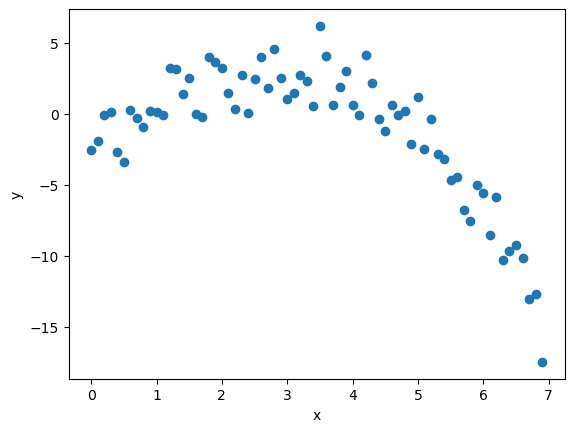

In [6]:
import matplotlib.pyplot as plt
# Your code for scatterplot here
plt.scatter(xy_data[:, 0], xy_data[:, 1])
plt.xlabel('x')
plt.ylabel('y')



### 1b) Write a function `polyreg` to fit a polynomial of a given order to a dataset. 
The inputs to the function are a data matrix of dimension $N \times 2$,  and $k \geq 0$, the order of the polynomial.   The function should compute the coefficients of the polynomial $\beta_0 + \beta_1 x +  \ldots  +\beta_k x^{k}$ via least squares regression, and should return the coefficient vector, the fit, and the vector of residuals. 

If specified the degree $k$ is greater than or equal to $N$, then the function must fit an order $(N-1)$ polynomial and set the remaining coefficients to zero.

**NOTE**: You are *not* allowed to use the built-in function `np.polyfit`.

In [ ]:
def polyreg(data_matrix, k):
    # Your code here
    # The function should return the the coefficient vector beta, the fit, and the vector of residuals
    if k < 0:
        raise ValueError("Degree of polynomial must be non-negative.")
    elif k >= data_matrix.shape[0]:
        k = data_matrix.shape[0] - 1
    x = data_matrix[:, 0]
    y = data_matrix[:, 1]
    X = np.vander(x, N=k + 1, increasing=True) # numpy method for constructing a matrix for polynomial regression, gives correct shape as per the input data
    
    betas = np.linalg.solve(X.T @ X, X.T @ y)
    fit = X @ betas
    residuals = y - fit
    print(X.shape)
    return betas, fit, residuals

Use the tests below to check the outputs of the function you have written:

In [9]:
# Some tests to make sure your function is working correctly

xcol = np.arange(-1, 1.05, 0.1)
ycol = 2 - 7*xcol + 3*(xcol**2)  # We are generating data accoridng to y = 2 - 7x + 3x^2
test_matrix = np.transpose(np.vstack((xcol,ycol)))
test_matrix.shape

beta_test = polyreg(test_matrix, k=2)[0] 
assert((np.round(beta_test[0], 3) == 2) and (np.round(beta_test[1], 3) == -7) and (np.round(beta_test[2], 3) == 3))  
# We want to check that using the function with k=2 recovers the coefficients exactly

# Now check the zeroth order fit, i.e., the function gives the correct output with k=0
beta_test = polyreg(test_matrix, k=0)[0]
res_test = polyreg(test_matrix, k=0)[2] #the last output of the function gives the vector of residuals

assert(np.round(beta_test, 3) == 3.1)
assert(np.round(np.linalg.norm(res_test), 3) == 19.937)

(21, 3)
(21, 1)
(21, 1)


### 1c) Use `polyreg` to fit polynomial models for the data in `xy_data` for $k=2,3,4$:

- Plot the fits for the three cases on the same plot together with the scatterplot of the data. The plots should be labelled and a legend included. 
- Compute and print the SSE and $R^2$ coefficient for each of the three cases.
- Which of the three models you would choose? Briefly justify your choice.

(70, 3)
(70, 4)
(70, 5)


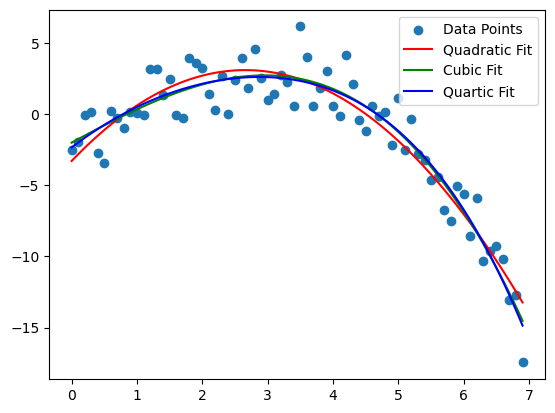

In [ ]:
#Your code here
# data poitn plot and fits for k=2,3,4
beta_2= polyreg(xy_data, k=2)[0] 
beta_3= polyreg(xy_data, k=3)[0] 
beta_4= polyreg(xy_data, k=4)[0] 

plt.scatter(xy_data[:, 0], xy_data[:, 1], label='Data Points')
x_fit = np.linspace(min(xy_data[:, 0]), max(xy_data[:, 0]), 100)
y_fit = beta_2[0] + beta_2[1]*x_fit + beta_2[2]*x_fit**2
plt.plot(x_fit, y_fit, color='red', label='Quadratic Fit')
y_fit = beta_3[0] + beta_3[1]*x_fit + beta_3[2]*x_fit**2 + beta_3[3]*x_fit**3
plt.plot(x_fit, y_fit, color='green', label='Cubic Fit')
y_fit = beta_4[0] + beta_4[1]*x_fit + beta_4[2]*x_fit**2 + beta_4[3]*x_fit**3 + beta_4[4]*x_fit**4
plt.plot(x_fit, y_fit, color='blue', label='Quartic Fit')
plt.legend()

In [20]:
# SSE and R^2 for k=2,3,4
res_2 = polyreg(xy_data, k=2)[2]
res_3 = polyreg(xy_data, k=3)[2]
res_4 = polyreg(xy_data, k=4)[2]   
SSE_2 = np.sum(res_2**2)
SSE_3 = np.sum(res_3**2)
SSE_4 = np.sum(res_4**2)    
var_xy = np.var(xy_data[:, 1]) * len(xy_data[:, 1]) 
R2_2 = 1 - (SSE_2 / var_xy)
R2_3 = 1 - (SSE_3 / var_xy)
R2_4 = 1 - (SSE_4 / var_xy)
print(f"SSE, R^2 for k=2: {SSE_2}, {R2_2}")
print(f"SSE, R^2 for k=3: {SSE_3}, {R2_3}")
print(f"SSE, R^2 for k=4: {SSE_4}, {R2_4}")

(70, 3)
(70, 4)
(70, 5)
SSE, R^2 for k=2: 172.18102528988553, 0.8876297774918223
SSE, R^2 for k=3: 152.40580488915808, 0.9005356474205022
SSE, R^2 for k=4: 151.22778969027107, 0.9013044535638858


 #### State which model you choose and briefly justify your choice.
 
i would choose the 4th order polynomial fit because it has the smallest average error/residual and the highest $R^2$ which indicates this model best predicts the variation, and hence is a good fit
 
 

### 1d)  For the model you have chosen in the previous part (either $k=2/3/4)$:

- Plot the residuals in a scatter plot. 
- Plot a histogram of the residuals along with a Gaussian pdf with zero mean and the same standard deviation as the residuals.

Mean of residuals =  -0.0 Variance of residuals =  2.177


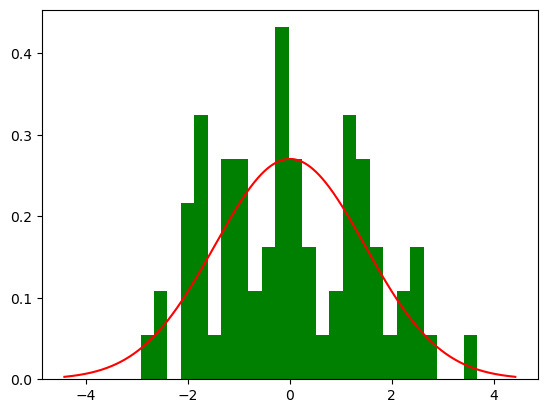

In [25]:
#Your code here

resid_lin = res_3

print('Mean of residuals = ', np.round(np.mean(resid_lin), 5), 'Variance of residuals = ', 
      np.round(np.var(resid_lin), 3))

# Plot normed histogram of the residuals
n, bins, patches = plt.hist(resid_lin, bins=25, density=True, facecolor='green')

# Plot Gaussian pdf with same mean and variance as the residuals
from scipy.stats import norm

res_stdev = np.std(resid_lin)  #standard deviation of residuals
xvals = np.linspace(-3*res_stdev,3*res_stdev,1000)
plt.plot(xvals, norm.pdf(xvals, loc=0, scale=res_stdev), 'r')
plt.show()